In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import re
import nltk
from nltk.corpus import stopwords

In [3]:
df = pd.read_csv(
    'classic-rock-raw-data.csv',
    engine='python',          # safer parser
    on_bad_lines='skip',      # skip broken rows
    quotechar='"',
    escapechar='\\'
)

In [4]:
print(df.head())
print(df.info())
print(df.columns)

              SONG RAW        Song Clean   ARTIST RAW ARTIST CLEAN CALLSIGN  \
0  Caught Up In (live)  Caught Up in You  .38 Special  .38 Special     KGLK   
1     Caught Up In You  Caught Up in You  .38 Special  .38 Special      KGB   
2     Caught Up In You  Caught Up in You  .38 Special  .38 Special      KGB   
3     Caught Up in You  Caught Up in You  .38 Special  .38 Special     KGLK   
4     Caught Up in You  Caught Up in You  .38 Special  .38 Special     KGLK   

         TIME UNIQUE_ID                         COMBINED  First?  
0  1402943314  KGLK1536  Caught Up in You by .38 Special       1  
1  1403398735   KGB0260  Caught Up in You by .38 Special       0  
2  1403243924   KGB0703  Caught Up in You by .38 Special       0  
3  1403470732  KGLK0036  Caught Up in You by .38 Special       0  
4  1403380737  KGLK0312  Caught Up in You by .38 Special       0  
<class 'pandas.DataFrame'>
RangeIndex: 37673 entries, 0 to 37672
Data columns (total 9 columns):
 #   Column        Non-Nul

In [6]:
df.rename(columns={'COMBINED': 'lyrics'}, inplace=True)
text_column = 'lyrics'

In [7]:
df = df.dropna(subset=[text_column])
df = df.reset_index(drop=True)

In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

In [10]:
df['clean_text'] = df[text_column].apply(clean_text)

In [11]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])

In [12]:
num_clusters = 5

kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10   # avoids sklearn warnings
)

df['cluster'] = kmeans.fit_predict(X)

In [13]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_pca = svd.fit_transform(X)

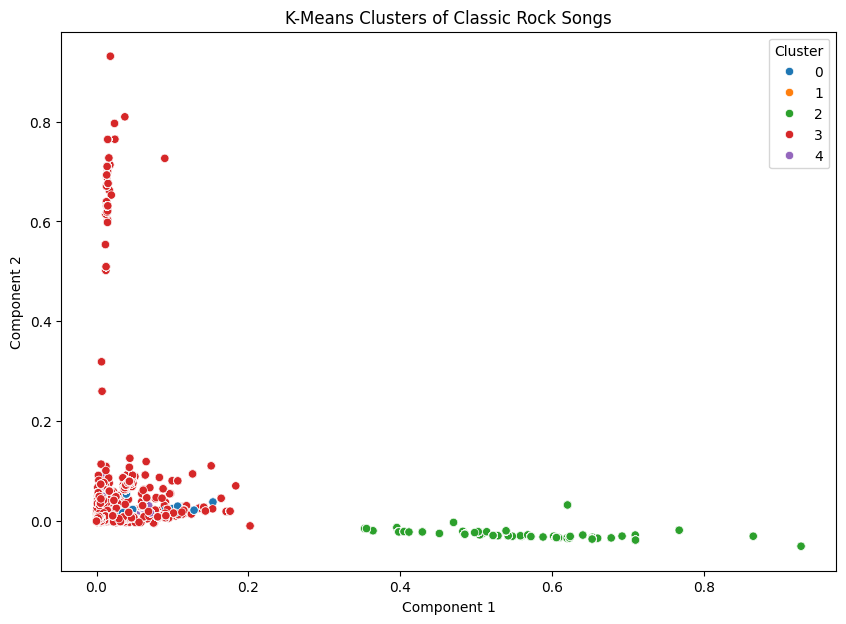

In [14]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['cluster'],
    palette='tab10'
)

plt.title('K-Means Clusters of Classic Rock Songs')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Cluster')
plt.show()

In [15]:
def print_top_words_per_cluster(model, vectorizer, n_words=10):
    terms = vectorizer.get_feature_names_out()
    
    for i, centroid in enumerate(model.cluster_centers_):
        top_terms = [terms[idx] for idx in centroid.argsort()[-n_words:][::-1]]
        print(f"\nCluster {i}:")
        print(", ".join(top_terms))

print_top_words_per_cluster(kmeans, vectorizer)


Cluster 0:
band, steve, miller, geils, rock, joker, run, allman, centerfold, brothers

Cluster 1:
talking, heads, burning, house, lifetime, late, stay, wartime, river, life

Cluster 2:
led, zeppelin, love, dog, ramble, immigrant, maker, dyer, song, hills

Cluster 3:
love, van, halen, rolling, stones, pink, floyd, tom, rock, beatles

Cluster 4:
way, long, foreigner, home, night, shook, acdc, time, walk, want
